In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDetermineBonds
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import math
import re

In [4]:
alf = pd.read_csv("./ALFABET_data/acp_new.csv")

In [5]:
alf

,Unnamed: 0,PID,Parent,Index,Child1,Child2,BDE,Bond,Heavy
0,0,1,NCCCC(=O)O,0,[CH2]CCC(=O)O,[NH2],86.584384,C-N,7.0
1,1,2,NCCCC(=O)O,1,[CH2]CC(=O)O,[CH2]N,83.222816,C-C,7.0
2,2,3,NCCCC(=O)O,2,[CH2]C(=O)O,[CH2]CN,87.547611,C-C,7.0
3,3,4,NCCCC(=O)O,3,O=[C]O,[CH2]CCN,95.963768,C-C,7.0
4,4,5,NCCCC(=O)O,5,NCCC[C]=O,[OH],111.470155,C-O,7.0
...,...,...,...,...,...,...,...,...,...
478268,478268,849896,C=CCC#N,4,[H],[CH]=CCC#N,111.743121,C-H,5.0
478269,478269,849897,C=CCC#N,5,[H],[CH]=CCC#N,111.743121,C-H,5.0
478270,478270,849898,C=CCC#N,6,[H],C=[C]CC#N,109.405021,C-H,5.0
478271,478271,849899,C=CCC#N,7,[H],C=C[CH]C#N,79.573221,C-H,5.0


In [6]:
#for i in range(len(alf)):
#    mol2 = Chem.MolFromSmiles(alf['Parent'][i])
#    alf['Heavy'][i] = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol2)

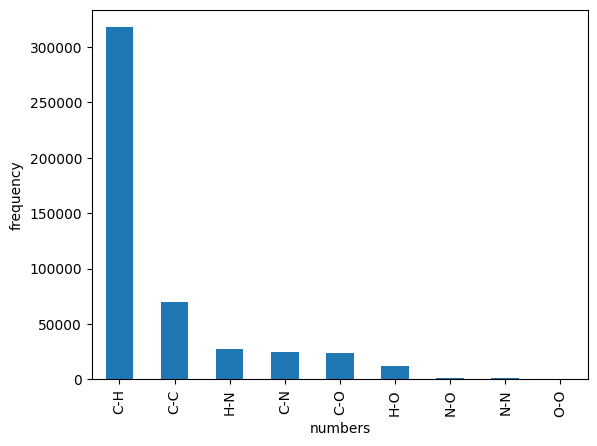

In [7]:
fig, ax = plt.subplots()
alf['Bond'].value_counts().plot(ax=ax, kind='bar', xlabel='numbers',ylabel='frequency')
plt.savefig("bond_frequency.svg")
#plt.show

Steps to computing distribution of pairwise bond lengths

1. store the xyz's within an array (simple)
2. For each atom within a bond, determine it's atomic index and compute the distance from that
3. Append this value to the list of distances for that particular bond (log it within some dataset as an additional column for reuse)

In [8]:
mol = Chem.MolFromXYZFile("ALFABET_data/xyz/johnbde_000001.xyz")

In [9]:
alf

,Unnamed: 0,PID,Parent,Index,Child1,Child2,BDE,Bond,Heavy
0,0,1,NCCCC(=O)O,0,[CH2]CCC(=O)O,[NH2],86.584384,C-N,7.0
1,1,2,NCCCC(=O)O,1,[CH2]CC(=O)O,[CH2]N,83.222816,C-C,7.0
2,2,3,NCCCC(=O)O,2,[CH2]C(=O)O,[CH2]CN,87.547611,C-C,7.0
3,3,4,NCCCC(=O)O,3,O=[C]O,[CH2]CCN,95.963768,C-C,7.0
4,4,5,NCCCC(=O)O,5,NCCC[C]=O,[OH],111.470155,C-O,7.0
...,...,...,...,...,...,...,...,...,...
478268,478268,849896,C=CCC#N,4,[H],[CH]=CCC#N,111.743121,C-H,5.0
478269,478269,849897,C=CCC#N,5,[H],[CH]=CCC#N,111.743121,C-H,5.0
478270,478270,849898,C=CCC#N,6,[H],C=[C]CC#N,109.405021,C-H,5.0
478271,478271,849899,C=CCC#N,7,[H],C=C[CH]C#N,79.573221,C-H,5.0


In [10]:
alf.to_csv("./ALFABET_data/acp_new.csv")

In [11]:
#AllChem.calcImplicitValence(mol)
mol = Chem.Mol(mol)
rdDetermineBonds.DetermineConnectivity(mol)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol)

0

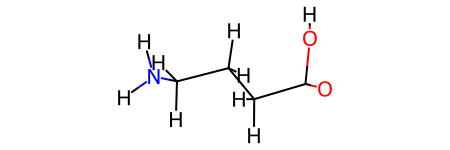

In [12]:
mol

In [13]:
mol2 = Chem.MolFromSmiles(alf['Parent'][0])

In [14]:
Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol2)

7

In [15]:
def computedistance(index1, index2, positions):
    return math.sqrt(((positions[index1][0] - positions[index2][0])**2) + ((positions[index1][1] - positions[index2][1])**2) + ((positions[index1][2] - positions[index2][2])**2))

In [25]:
fodd = Chem.MolFromSmiles("NCCCC(=O)O")
fodd = Chem.AddHs(fodd)
for bonds in fodd.GetBonds():
        frag = fodd.GetAtomWithIdx(bonds.GetBeginAtomIdx()).GetSymbol() + '-' + fodd.GetAtomWithIdx(bonds.GetEndAtomIdx()).GetSymbol()
        print(str(bonds.GetIdx()) + ", " + str(frag))

0, N-C
1, C-C
2, C-C
3, C-C
4, C-O
5, C-O
6, N-H
7, N-H
8, C-H
9, C-H
10, C-H
11, C-H
12, C-H
13, C-H
14, O-H


In [45]:
fodd = Chem.MolFromSmiles("NCCCC(=O)O")
print(fodd.GetBonds()[5].GetIdx())

5


In [40]:

#move count to outside the function and pass it as a parameter
def logmoldistances(mol, dfset):
    #count = 0
    #for every bond, compute distance, log it alongside bond-type
    mol = Chem.Mol(mol)
    #rdDetermineBonds.DetermineConnectivity(mol)
    mol = Chem.AddHs(mol)
    arr = mol.GetConformer().GetPositions()
    #AllChem.EmbedMolecule(mol)
    for bonds in mol.GetBonds():
        frag = mol.GetAtomWithIdx(bonds.GetBeginAtomIdx()).GetSymbol() + '-' + mol.GetAtomWithIdx(bonds.GetEndAtomIdx()).GetSymbol()
        print(str(bonds.GetIdx()) + ", " + str(frag))
        if frag not in dfset:
            dfset[frag] = pd.DataFrame(columns=['BondType', 'Distance'])
        
        dfset[frag].loc[len(dfset[frag])] = [frag] + [computedistance(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx(), arr)]
        #df.loc[count] = [frag] + [computedistance(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx(), arr)]
        #print(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx())
        #count = count + 1
    

Make function to iterate over all of molecules in folder

In [23]:
mol = Chem.MolFromXYZFile("ALFABET_data/xyz/johnbde_000001.xyz")
df2 = {}
logmoldistances(mol, df2)

0, N-C
1, N-H
2, N-H
3, C-C
4, C-H
5, C-H
6, C-C
7, C-H
8, C-H
9, C-C
10, C-H
11, C-H
12, C-O
13, C-O
14, O-H


In [41]:
mol = Chem.MolFromMolFile("ALFABET_data/output.sdf")
df3 = {}
logmoldistances(mol, df3)

0, N-C
1, C-C
2, C-C
3, C-C
4, C-O
5, O-C
6, N-H
7, N-H
8, C-H
9, C-H
10, C-H
11, C-H
12, C-H
13, C-H
14, O-H


In [34]:
print(df2['C-H'])


  BondType  Distance
0      C-H  1.094170
1      C-H  1.091654
2      C-H  1.094204
3      C-H  1.091083
4      C-H  1.087037
5      C-H  1.095093


In [36]:
df2['C-H']['Distance'].mean()

1.0922067905335078

In [17]:
#fig, ax = plt.subplots()
df['Distance'].mean()
#df['BondType'].mean().plot(ax=ax, kind='bar', xlabel='numbers',ylabel='frequency')
#plt.savefig("bond_frequency.svg")
#plt.show

1.2104833939385258

In [38]:
alf

,PID,Parent,??,Child1,Child2,BDE,Bond
0,1,NCCCC(=O)O,0,[CH2]CCC(=O)O,[NH2],86.584384,C-N
1,2,NCCCC(=O)O,1,[CH2]CC(=O)O,[CH2]N,83.222816,C-C
2,3,NCCCC(=O)O,2,[CH2]C(=O)O,[CH2]CN,87.547611,C-C
3,4,NCCCC(=O)O,3,O=[C]O,[CH2]CCN,95.963768,C-C
4,5,NCCCC(=O)O,5,NCCC[C]=O,[OH],111.470155,C-O
...,...,...,...,...,...,...,...
478268,849896,C=CCC#N,4,[H],[CH]=CCC#N,111.743121,C-H
478269,849897,C=CCC#N,5,[H],[CH]=CCC#N,111.743121,C-H
478270,849898,C=CCC#N,6,[H],C=[C]CC#N,109.405021,C-H
478271,849899,C=CCC#N,7,[H],C=C[CH]C#N,79.573221,C-H


In [90]:
alf.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478273 entries, 0 to 478272
Columns: 9 entries, Unnamed: 0 to Heavy
dtypes: float64(2), int64(3), object(4)
memory usage: 140.8 MB


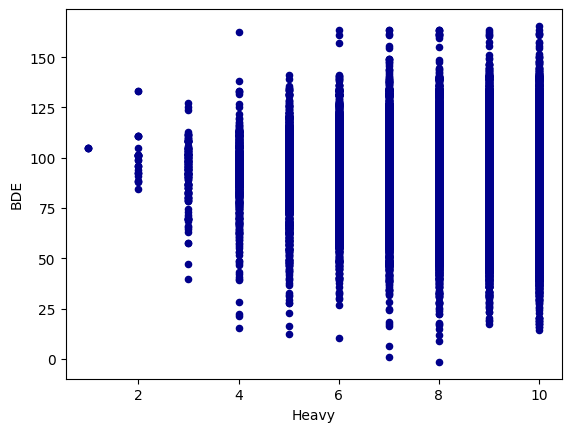

In [91]:
ax1 = alf.plot.scatter(x='Heavy',y='BDE',c='DarkBlue')